In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import os
import scipy.io
from typing import Tuple, List
from enum import Enum, auto
from dataclasses import dataclass

import sys
sys.path.insert(0, '../')
sys.path.insert(0, '../vae')
sys.path.insert(0, '../fluid_TO')
sys.path.insert(0, '../dataset')
import dataset.supershape as supershape
import yaml
import material_constants
import fluid_mesher
import fluid_bcs
import fluid_material
import fluid_fe
import projection
import neural_network
import loss
import utils
import plot
import opt_constraints
import torch.optim as optim

import vae.network as vae_network
import vae.data_preprocess as vae_data_prep
import vae.train_vae as train_vae

import time
start_time = time.time()


C:\Users\Bingxiao Du\AppData\Local\Temp\ipykernel_51100\3910422373.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Read Config File

In [2]:
with open("config_diffuser.yaml", "r") as file:
    config_data = yaml.safe_load(file)

# Fluid Mesh

In [3]:
bounding_box = fluid_mesher.BoundingBox(x_min= config_data["BOUNDING_BOX"]["x_min"],
                                    x_max= config_data["BOUNDING_BOX"]["x_max"],
                                    y_min= config_data["BOUNDING_BOX"]["y_min"],
                                    y_max= config_data["BOUNDING_BOX"]["y_max"])

fluid_mesh = fluid_mesher.fluid_mesher(nelx = config_data["MESH"]["nelx"],
                                        nely = config_data["MESH"]["nely"], 
                                        bounding_box=bounding_box)

# Boundary Conditions

In [4]:
char_velocity = config_data["BOUNDARY_CONDITIONS"]["char_velocity"]
fluid_bc = fluid_bcs.get_dirichlet_bc_and_fixed_dofs(
    fluid_mesh, char_velocity, fluid_bcs.FluidSampleProblems[
      config_data["BOUNDARY_CONDITIONS"]["example"]])

# Fluid Material

In [5]:
fluid_mat_constants = material_constants.MaterialConstants(
                                        kinematic_viscosity =  config_data[
                                          "MATERIAL_CONSTANTS"][
                                          "kinematic_viscosity"])
                                            
fluid_material = fluid_material.FluidMaterial(fluid_mesh.elem_dx,
            fluid_mesh.elem_dy,
            fluid_mat_constants)

# Fluid Solver

In [6]:
fluid_solver = fluid_fe.FluidSolver(fluid_mesh, fluid_bc,
                                    fixture_const = 
                                    config_data["BOUNDARY_CONDITIONS"]
                                    ["fixture_const"])

# Initialize Neural Network

In [7]:
fourier_map = projection.FourierMap(fluid_mesh,
  fourier_map_activation = ( projection.FourierActivation
                            [config_data["FOURIER_MAP_PARAMS"]
                              ["fourier_map_activation"]]),
  num_fourier_terms = config_data["FOURIER_MAP_PARAMS"][
                                      "num_fourier_terms"],
  max_radius = config_data["FOURIER_MAP_PARAMS"]["max_radius"],
  min_radius = config_data["FOURIER_MAP_PARAMS"]["min_radius"])

symmetry_activation_x_axis = projection.SymmetryActivation.SYM_X_AXIS_ON
symmetry_activation_y_axis = projection.SymmetryActivation.SYM_Y_AXIS_OFF

constraint_type = opt_constraints.ConstraintType[config_data["OPTIMIZATION"]
                                                   ["constraint_type"]]
nn_settings = neural_network.NeuralNetworkParameters(input_dim = 2*config_data["FOURIER_MAP_PARAMS"]
                                                      ["num_fourier_terms"],
                                                      output_dim = config_data["NEURAL_NETWORK_PARAMS"]
                                                      ["output_dim"],
                                                      num_layers = config_data["NEURAL_NETWORK_PARAMS"]
                                                      ["num_layers"],
                                                      num_neurons_per_layer=config_data["NEURAL_NETWORK_PARAMS"]
                                                      ["num_neurons_per_layer"])

neural_net = neural_network.TopOptNet(nn_params=nn_settings)



# Load VAE

In [8]:
folder_path = "../vae"
file_name = "vae_net.pt"
file_path = os.path.join(folder_path, file_name)
with open("vae_config.yaml", "r") as file:
  vae_config_data = yaml.safe_load(file)
vae_yaml = vae_config_data['NETWORK']
vae_yaml = vae_config_data['NETWORK']
vae_params = vae_network.VAE_Params(input_dim=12,
                                encoder_hidden_dim=vae_yaml['encoder_hidden_dim'],
                                latent_dim=vae_yaml['latent_dim'],
                                decoder_hidden_dim=vae_yaml['decoder_hidden_dim'])
vae_net = vae_network.VariationalAutoencoder(vae_params=vae_params)
vae_net.encoder.is_training = False
vae_net.load_state_dict(torch.load(file_path))
vae_net.eval()
nomalization = torch.load('../vae/nomalization.pt')
max_feature = nomalization['max_feature']
min_feature = nomalization['min_feature']
print("Loading VAE")
normalization_types = [vae_data_prep.NomalizationType.LINEAR] * 8 + [vae_data_prep.NomalizationType.LOG] * 2 + [vae_data_prep.NomalizationType.LINEAR] * 2


Loading VAE


# Project Coordinates

In [9]:
def calculate_projected_coordinates( fluid_sym_map, res: int)->torch.Tensor:
  """
  Calculates the projected coordinates of fluid elements based on the
  specified resolution, reflection and fourier map.
  
  Args:
    res: Resolution parameter indicating the desired resolution in the sampled points.
  
  Returns:
    fluid_xy_f: Tensor of size (num_elems, 2) representing the projected coordinates
                of fluid elements.
  """
  if (res == 1):
    fluid_xy = torch.tensor(fluid_solver.mesh.elem_centers, 
                        requires_grad=True).double() 
    
  else:
    elem_centers = utils.generate_points_in_domain(fluid_mesher.nelx,
                                    fluid_mesher.nely,
                                    fluid_mesher.elem_dx,
                                    fluid_mesher.elem_dy, 
                                    fluid_mesher.num_dim,
                                    res)
    fluid_xy = torch.tensor(elem_centers, 
                          requires_grad=True).double() 
  
  fluid_xy_r, fluid_signs_reflection = projection.apply_reflection(fluid_xy,
                                                                  symmetry_activation_y_axis,
                                                                  symmetry_activation_x_axis,
                                                                  fluid_sym_map)
  
  
  if(fourier_map.fourier_map_activation == projection.FourierActivation.FOURIER_ON):
    fluid_xy_f = fourier_map.apply_fourier_map(fluid_xy_r)
  
  return fluid_xy_f, fluid_signs_reflection 

# Optimize Design

In [10]:
class Optimizer(Enum):
  ADAM = auto()
  LBFGS = auto()
  
class GradClipActivation(Enum):
  GRAD_CLIP_ON = auto()
  GRAD_CLIP_OFF = auto()

@dataclass
class OptimizationSettings:
  plot_interval: int
  lr: float
  num_epochs: int
  method : int
  grad_clip_activation: int
  grad_clip_norm: float

@dataclass 
class OptimizationInitials:
  J0 : float
  constraints : np.ndarray

def optimize_design(opt_params: OptimizationSettings, loss_type:loss.LossTypes,
                    loss_params:loss.AugmentedLagrangianParameters,
                    opt_initials:OptimizationInitials,
                    constraint_type: opt_constraints.ConstraintType, sym_params: projection.SymParams,
                     desired_vol_frac:float, desired_perimeter: float, perim_scale = 2.):
  """
  Optimize the design using the specified optimization parameters.

  Args:
      opt_params: Object representing the optimization settings.
      loss_type: Enum representing the type of loss function to be used.
      loss_params: Parameters for the augmented Lagrangian loss function.
      opt_initials: Initial values for optimization parameters.
      penalty_constants: Constants for the penalization.

  Returns:
      convergence_history: Dictionary containing lists of convergence values for each epoch.

  """
  epoch = 0
  convergence_history = {'epoch':[], 'perimeter':[], 'fluid_loss':[]}
  
  fluid_xy_f, fluid_signs_reflection = calculate_projected_coordinates(sym_params, res = 1.)
  
  if(opt_params.method == Optimizer.ADAM):
      print('Adam working')
      optimizer = optim.Adam(neural_net.parameters(), amsgrad=True, 
                              lr=opt_params.lr)  
      
  else:
      print('LBFGS working')
      optimizer = optim.LBFGS(neural_net.parameters(),
                                    line_search_fn = 'strong_wolfe')
        
  def loss_wrapper( eps = 1e-6)-> Tuple[torch.Tensor, torch.Tensor, List, torch.Tensor,
                              supershape.SuperShapes]:
    """
    Calculates the loss and related parameters for the optimization process.
    While data generation the fluid has density 1. and solid has 0, 
    but while getting the calculating the area it gives solid area.
    Therefore the decoder gives the supershape's solid area and we substract it from 1.
    to get the fluid volume fraction.

    Returns:
        net_loss: Tensor of size (1,) representing the combined loss value.
        fluid_loss: Tensor of size (1,) representing the fluid loss value.
        constraints: List of size (num_constraints,) constraint values. Currently it only contains fluid
                    volume constraint.
        fluid_vol_frac: Tensor of size (num_elems) and representing the fluid volume fraction.
        mstr_params: Object containing arrays of number num_geometric_params
                      where each array is of size (num_elems)
                      representing the renormalized geometric parameters
                      of the microstructures.
  """
    optimizer.zero_grad()
    latent_space, theta = neural_net(fluid_xy_f)
    theta = torch.einsum('i,i->i', theta, fluid_signs_reflection['X'])
    theta = torch.einsum('i,i->i', theta, fluid_signs_reflection['Y'])
    decoded_latent_pt = vae_net.decoder(latent_space)
    vae_output_renormalized = vae_data_prep.stack_vae_output(decoded_latent_pt, max_feature, min_feature, normalization_types)

    if(constraint_type == opt_constraints.ConstraintType.VOLUME):
      constraint_field = vae_output_renormalized[:, vae_data_prep.VAE_Fields.shape_area.value]
    elif(constraint_type == opt_constraints.ConstraintType.PERIMETER):
      constraint_field = fluid_solver.mesh.elem_dx*perim_scale*vae_output_renormalized[:, vae_data_prep.VAE_Fields.shape_perim.value]

    C_00 = vae_output_renormalized[:, vae_data_prep.VAE_Fields.homog_c00.value] + eps
    C_11 = vae_output_renormalized[:, vae_data_prep.VAE_Fields.homog_c11.value] + eps
    mstr_data = vae_output_renormalized[:, :vae_data_prep.VAE_Fields.homog_c00.value].clone().detach().numpy()
    mstr_params  = supershape.SuperShapes(mstr_data[:, 0], mstr_data[:, 1], mstr_data[:, 2], mstr_data[:, 3],
                   mstr_data[:, 4], mstr_data[:, 5], mstr_data[:, 6], mstr_data[:, 7])
    
    fluid_loss, velocity_pressure_field = fluid_solver.fluid_objective_function( fluid_material, C_00, C_11, theta)
    
    field_cons_value = opt_constraints.constraint_function(constraint_type, constraint_field, desired_vol_frac, desired_perimeter) 
    if(epoch == 0 or epoch == 20):
      opt_initials.J0 = (fluid_loss.item()) 
      
  
    opt_params.constraints = [field_cons_value]
    net_loss = loss.combined_loss(
      objective = fluid_loss/opt_initials.J0,              
      constraints = opt_params.constraints,
      loss_type = loss_type,
      loss_params = loss_params,
      epoch = epoch)
    return (net_loss, fluid_loss, opt_params.constraints, constraint_field,
            mstr_params, C_00, C_11, theta)
  
  
  def closure() -> torch.Tensor:
    """
      Closure function for the optimizer.
  
      This function performs a forward pass to calculate the total loss,
      backward pass to compute gradients, and applies gradient clipping.
      It returns the total loss.
  
      Returns:
          net_loss: Tensor of size (1,)representing the total loss.
    """
    
    optimizer.zero_grad()
    (net_loss, fluid_loss, constraint, constraint_field, mstr_params,
    C_00, C_11, theta)= loss_wrapper()
    net_loss.backward(retain_graph = True)
    
    torch.nn.utils.clip_grad_norm_(neural_net.parameters(),
                                    opt_params.grad_clip_norm)
    return net_loss 
  
  
  for epoch in range(opt_params.num_epochs):
    net_loss = closure()
    if(opt_params.method == 'adam'):
        
      optimizer.step()
        
    else:

      optimizer.step(closure)
      
    loss.update_loss_parameters(epoch, loss_type, loss_params, opt_params.constraints)  
    (net_loss, fluid_loss, constraint, constraint_field,
      mstr_params, C_00, C_11, theta) = loss_wrapper()
    net_loss.backward(retain_graph = True)
    convergence_history['epoch'].append(epoch)
    convergence_history['perimeter'].append(torch.sum(constraint_field).item())
    convergence_history['fluid_loss'].append(fluid_loss.item())
    
    status = "Iter {:3d} J: {:.2E}; perimeter : {:.2F} "\
      .format(epoch, fluid_loss.item(), torch.sum(constraint_field).item())
    print(status)
    
    if(epoch % opt_params.plot_interval == 0):

      theta = theta.clone().detach().numpy()
      plot.plot_microstructures_in_macro_mesh(mstr_params,
                                              theta,
                                              fluid_solver.mesh.nelx,
                                              fluid_solver.mesh.nely, 
                                              epoch)
  
  
  return convergence_history

# Optimization Settings

In [11]:
sym_params = projection.SymParams(sym_x_axis_mid_pt = 0.5*config_data["BOUNDING_BOX"]["y_max"],
                                  sym_y_axis_mid_pt = 0.5*config_data["BOUNDING_BOX"]["x_max"])

num_constraints = config_data["OPTIMIZATION"]["num_constraints"]
desired_vol_frac = config_data["OPTIMIZATION"]["desired_vol_frac"]
desired_perimeter = config_data["OPTIMIZATION"]["desired_perimeter"]

loss_type = loss.LossTypes[config_data["LOSS"]["method"]]


loss_params = loss.PenaltyLossParameters(
              alpha0 = config_data["LOSS"]["alpha0"],
              del_alpha = config_data["LOSS"]["del_alpha"])

opt_initials = OptimizationInitials( 
                J0 = config_data["OPTIMIZATION"]["init_objective"], 
  constraints = np.zeros((num_constraints)))

opt_params = OptimizationSettings(
              plot_interval =  config_data["OPTIMIZATION"]["plot_interval"],
              lr = config_data["OPTIMIZATION"]["learning_rate"],
              num_epochs= config_data["OPTIMIZATION"]["num_epochs"], 
              method = Optimizer[config_data["OPTIMIZATION"]["method"]],
              grad_clip_activation = GradClipActivation[
                                      config_data["OPTIMIZATION"]
                                      ["grad_clip_activation"]],
              grad_clip_norm = config_data["OPTIMIZATION"]
                                ["grad_clip_norm"]
  )


Adam working


C:\Users\Bingxiao Du\Documents\TOMAS\notebooks\../fluid_TO\fluid_fe.py:163: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:264.)
  assembled_A_matrix =  torch.sparse_coo_tensor(


Iter   0 J: 3.04E+02; perimeter : 82.15 


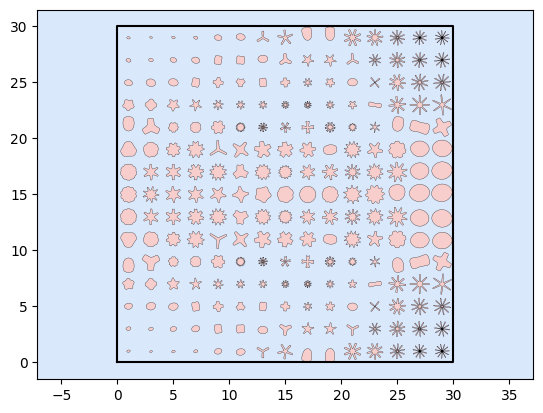

Iter   1 J: 2.25E+02; perimeter : 77.97 


Iter   2 J: 1.80E+02; perimeter : 76.00 


Iter   3 J: 1.40E+02; perimeter : 72.13 


Iter   4 J: 1.65E+02; perimeter : 68.00 


Iter   5 J: 1.33E+02; perimeter : 61.61 


...

Iter  16 J: 3.65E+01; perimeter : 59.29 


Iter  17 J: 3.44E+01; perimeter : 60.15 


Iter  18 J: 3.25E+01; perimeter : 60.08 


Iter  19 J: 3.12E+01; perimeter : 59.52 


Iter  20 J: 3.00E+01; perimeter : 58.67 


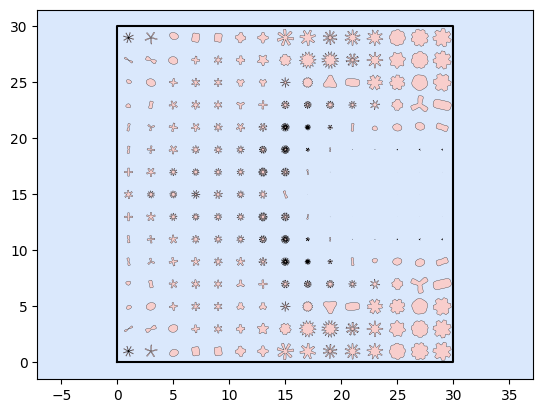

Iter  21 J: 2.89E+01; perimeter : 57.06 


Iter  22 J: 2.75E+01; perimeter : 56.87 


Iter  23 J: 2.64E+01; perimeter : 57.27 


Iter  24 J: 2.57E+01; perimeter : 57.21 


Iter  25 J: 2.47E+01; perimeter : 57.80 


...

Iter  36 J: 1.94E+01; perimeter : 58.54 


Iter  37 J: 1.92E+01; perimeter : 57.74 


Iter  38 J: 1.90E+01; perimeter : 57.96 


Iter  39 J: 1.89E+01; perimeter : 58.77 


Iter  40 J: 1.88E+01; perimeter : 58.99 


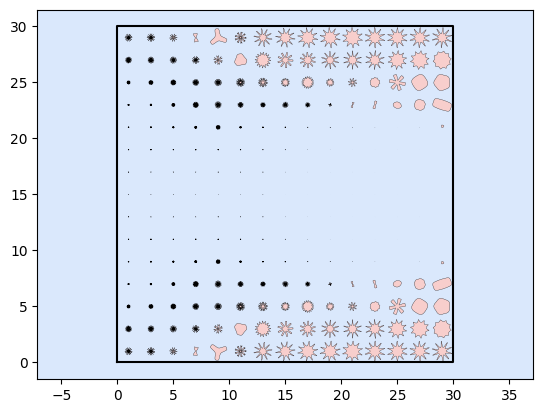

Iter  41 J: 1.86E+01; perimeter : 58.01 


Iter  42 J: 1.85E+01; perimeter : 57.89 


Iter  43 J: 1.85E+01; perimeter : 58.90 


Iter  44 J: 1.84E+01; perimeter : 60.13 


Iter  45 J: 1.83E+01; perimeter : 60.15 


...

Iter  56 J: 1.79E+01; perimeter : 59.89 


Iter  57 J: 1.78E+01; perimeter : 59.16 


Iter  58 J: 1.78E+01; perimeter : 59.19 


Iter  59 J: 1.78E+01; perimeter : 59.85 


Iter  60 J: 1.78E+01; perimeter : 59.64 


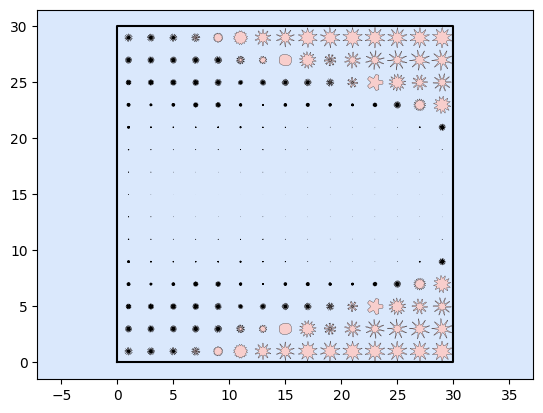

Iter  61 J: 1.77E+01; perimeter : 59.24 


Iter  62 J: 1.77E+01; perimeter : 59.49 


Iter  63 J: 1.77E+01; perimeter : 60.25 


Iter  64 J: 1.77E+01; perimeter : 59.99 


Iter  65 J: 1.77E+01; perimeter : 58.93 


...

Iter  76 J: 1.76E+01; perimeter : 58.60 


Iter  77 J: 1.76E+01; perimeter : 59.29 


Iter  78 J: 1.76E+01; perimeter : 60.67 


Iter  79 J: 1.77E+01; perimeter : 60.68 


Iter  80 J: 1.76E+01; perimeter : 59.69 


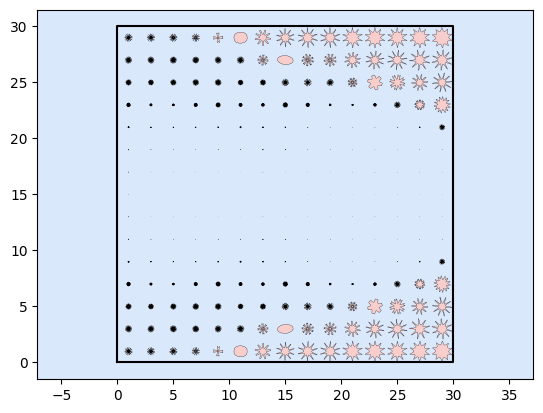

Iter  81 J: 1.76E+01; perimeter : 58.82 


Iter  82 J: 1.76E+01; perimeter : 58.91 


Iter  83 J: 1.76E+01; perimeter : 59.46 


Iter  84 J: 1.77E+01; perimeter : 60.92 


Iter  85 J: 1.77E+01; perimeter : 60.59 


...

Iter  96 J: 1.75E+01; perimeter : 59.64 


Iter  97 J: 1.75E+01; perimeter : 59.80 


Iter  98 J: 1.75E+01; perimeter : 59.51 


Iter  99 J: 1.75E+01; perimeter : 59.82 


Iter 100 J: 1.74E+01; perimeter : 59.33 


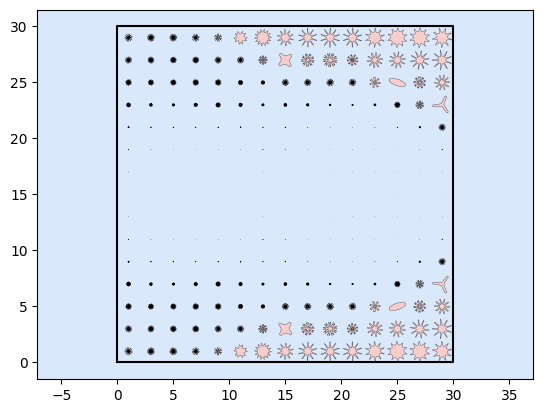

Iter 101 J: 1.75E+01; perimeter : 59.73 


Iter 102 J: 1.74E+01; perimeter : 60.00 


Iter 103 J: 1.74E+01; perimeter : 59.06 


Iter 104 J: 1.74E+01; perimeter : 58.94 


Iter 105 J: 1.75E+01; perimeter : 59.84 


...

Iter 116 J: 1.74E+01; perimeter : 59.01 


Iter 117 J: 1.74E+01; perimeter : 59.83 


Iter 118 J: 1.74E+01; perimeter : 59.89 


Iter 119 J: 1.74E+01; perimeter : 58.65 


Iter 120 J: 1.74E+01; perimeter : 58.33 


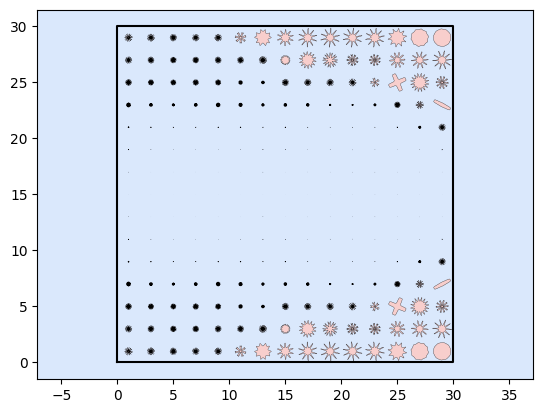

Iter 121 J: 1.74E+01; perimeter : 59.19 


Iter 122 J: 1.74E+01; perimeter : 60.93 


Iter 123 J: 1.75E+01; perimeter : 61.11 


Iter 124 J: 1.75E+01; perimeter : 60.37 


Iter 125 J: 1.74E+01; perimeter : 58.79 


...

Iter 136 J: 1.74E+01; perimeter : 58.89 


Iter 137 J: 1.75E+01; perimeter : 60.18 


Iter 138 J: 1.74E+01; perimeter : 60.31 


Iter 139 J: 1.74E+01; perimeter : 59.11 


Iter 140 J: 1.74E+01; perimeter : 59.65 


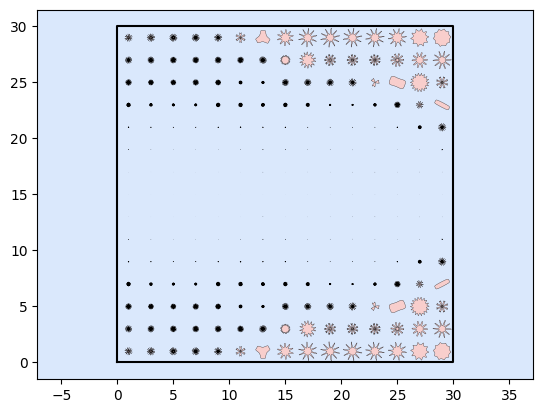

Iter 141 J: 1.74E+01; perimeter : 60.83 


Iter 142 J: 1.74E+01; perimeter : 60.65 


Iter 143 J: 1.74E+01; perimeter : 59.32 


Iter 144 J: 1.74E+01; perimeter : 59.10 


Iter 145 J: 1.74E+01; perimeter : 59.73 


...

Iter 156 J: 1.74E+01; perimeter : 60.52 


Iter 157 J: 1.74E+01; perimeter : 59.75 


Iter 158 J: 1.73E+01; perimeter : 59.60 


Iter 159 J: 1.74E+01; perimeter : 60.03 


Iter 160 J: 1.73E+01; perimeter : 59.62 


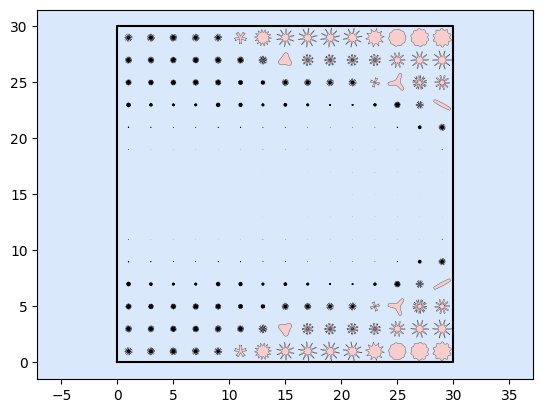

Iter 161 J: 1.73E+01; perimeter : 60.08 


Iter 162 J: 1.73E+01; perimeter : 59.43 


Iter 163 J: 1.73E+01; perimeter : 59.66 


Iter 164 J: 1.73E+01; perimeter : 60.06 


Iter 165 J: 1.73E+01; perimeter : 59.51 


...

Iter 176 J: 1.74E+01; perimeter : 59.83 


Iter 177 J: 1.74E+01; perimeter : 60.42 


Iter 178 J: 1.73E+01; perimeter : 60.08 


Iter 179 J: 1.73E+01; perimeter : 58.72 


Iter 180 J: 1.73E+01; perimeter : 58.20 


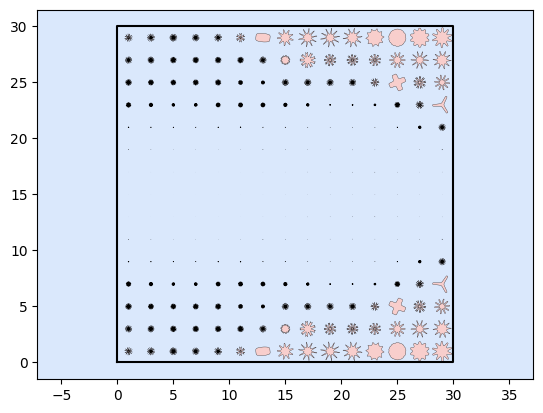

Iter 181 J: 1.73E+01; perimeter : 58.68 


Iter 182 J: 1.73E+01; perimeter : 59.90 


Iter 183 J: 1.73E+01; perimeter : 59.96 


Iter 184 J: 1.73E+01; perimeter : 59.25 


Iter 185 J: 1.73E+01; perimeter : 59.58 


...

Iter 196 J: 1.73E+01; perimeter : 60.28 


Iter 197 J: 1.73E+01; perimeter : 60.23 


Iter 198 J: 1.73E+01; perimeter : 59.49 


Iter 199 J: 1.73E+01; perimeter : 59.66 


Iter 200 J: 1.73E+01; perimeter : 60.48 


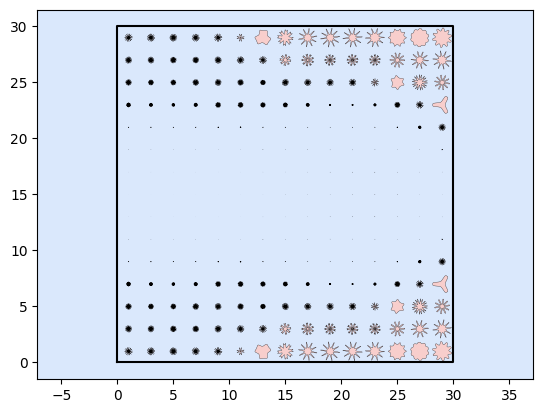

Iter 201 J: 1.73E+01; perimeter : 60.17 


Iter 202 J: 1.73E+01; perimeter : 58.97 


Iter 203 J: 1.73E+01; perimeter : 58.82 


Iter 204 J: 1.73E+01; perimeter : 59.43 


Iter 205 J: 1.74E+01; perimeter : 60.75 


...

Iter 216 J: 1.74E+01; perimeter : 61.48 


Iter 217 J: 1.74E+01; perimeter : 62.04 


Iter 218 J: 1.74E+01; perimeter : 61.28 


Iter 219 J: 1.73E+01; perimeter : 59.12 


Iter 220 J: 1.73E+01; perimeter : 58.54 


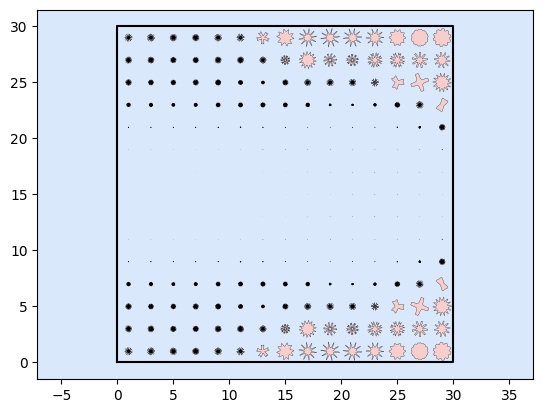

Iter 221 J: 1.73E+01; perimeter : 59.22 


Iter 222 J: 1.74E+01; perimeter : 60.76 


Iter 223 J: 1.74E+01; perimeter : 60.99 


Iter 224 J: 1.74E+01; perimeter : 60.01 


Iter 225 J: 1.73E+01; perimeter : 58.77 


...

Iter 236 J: 1.73E+01; perimeter : 60.32 


Iter 237 J: 1.73E+01; perimeter : 59.65 


Iter 238 J: 1.73E+01; perimeter : 59.92 


Iter 239 J: 1.73E+01; perimeter : 60.03 


Iter 240 J: 1.72E+01; perimeter : 58.80 


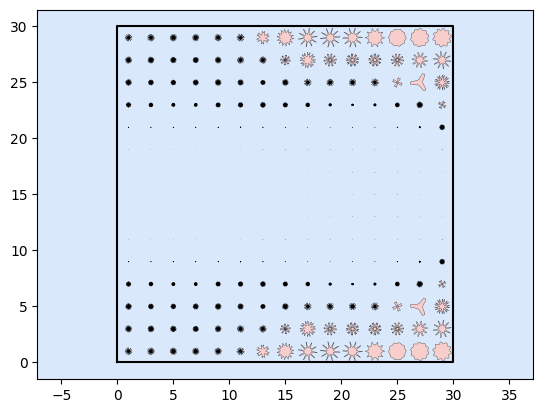

Iter 241 J: 1.72E+01; perimeter : 58.22 


Iter 242 J: 1.73E+01; perimeter : 58.62 


Iter 243 J: 1.73E+01; perimeter : 59.83 


Iter 244 J: 1.73E+01; perimeter : 61.31 


Iter 245 J: 1.74E+01; perimeter : 61.34 


...

Iter 256 J: 1.73E+01; perimeter : 59.93 


Iter 257 J: 1.73E+01; perimeter : 59.43 


Iter 258 J: 1.73E+01; perimeter : 58.87 


Iter 259 J: 1.74E+01; perimeter : 58.93 


Iter 260 J: 1.74E+01; perimeter : 59.72 


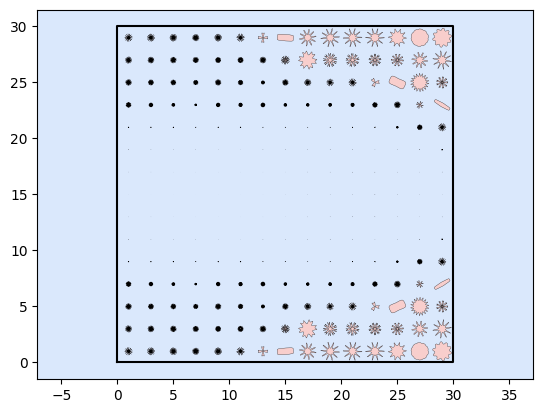

Iter 261 J: 1.75E+01; perimeter : 61.20 


Iter 262 J: 1.75E+01; perimeter : 61.60 


Iter 263 J: 1.75E+01; perimeter : 61.10 


Iter 264 J: 1.75E+01; perimeter : 59.94 


Iter 265 J: 1.74E+01; perimeter : 58.72 


...

Iter 276 J: 1.73E+01; perimeter : 59.85 


Iter 277 J: 1.73E+01; perimeter : 58.58 


Iter 278 J: 1.72E+01; perimeter : 57.79 


Iter 279 J: 1.72E+01; perimeter : 57.96 


Iter 280 J: 1.72E+01; perimeter : 58.83 


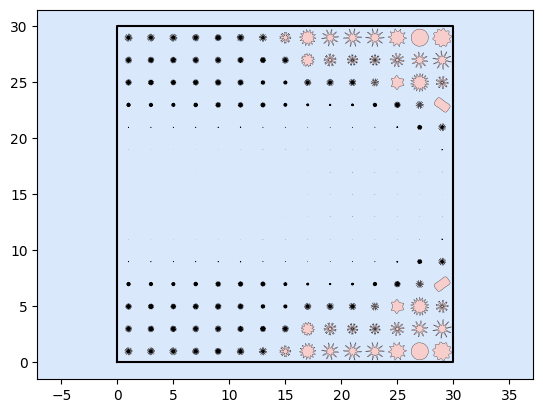

Iter 281 J: 1.73E+01; perimeter : 60.24 


Iter 282 J: 1.74E+01; perimeter : 60.61 


Iter 283 J: 1.74E+01; perimeter : 60.11 


Iter 284 J: 1.73E+01; perimeter : 58.96 


Iter 285 J: 1.73E+01; perimeter : 58.86 


...

Iter 296 J: 1.73E+01; perimeter : 59.57 


Iter 297 J: 1.73E+01; perimeter : 60.52 


Iter 298 J: 1.73E+01; perimeter : 60.18 


Iter 299 J: 1.72E+01; perimeter : 58.64 


Iter 300 J: 1.72E+01; perimeter : 58.41 


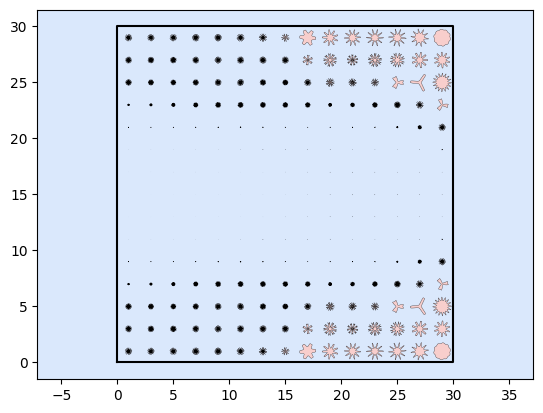

In [12]:
plt.close('all')
gpu_status = utils.Gpu.OVERRIDE
convg_history = optimize_design( opt_params, loss_type, loss_params, opt_initials, constraint_type, sym_params, desired_vol_frac, desired_perimeter)